In this notebook, we continue with the analysis of implied volatility index: VIX.

Workflow:
PROJECT 2
1. Model the differences of log-vix data
2. Kalman filter
- definition of the state space
- state space model
- RLS algorithm with adaptive Q and R
3. non-linear filters
- UKF
- attempt for adaptive Q and R


PROJECT 3
1. Make an LSTM model to perform bagging on KF and UKF predictions
2. Implement Black-Sholes formula
- standard Black-Sholes for calculating the price of a European call option (betting that the price will be at or higher than a given 'strike' price)
3. Develop a simple decision rule, when to buy that option
4. Evaluate the results





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PROJECT 2

We are going to model the log-differences of VIX values, let $v_t = \log (vix_t)$:
$$y_t = \Delta v_t= v_t - v_{t-1}, \quad vix_t = \exp(v_t) = \exp(v_{t-1} + \Delta v_t) = \exp(v_{t-1} + y_t)$$

         date     spy    vix   sp20vol
0  2007-01-03  141.37  12.04  0.067240
1  2007-01-04  141.67  11.51  0.060006
2  2007-01-05  140.54  12.14  0.062457
3  2007-01-08  141.19  12.00  0.062858
4  2007-01-09  141.07  11.91  0.061132


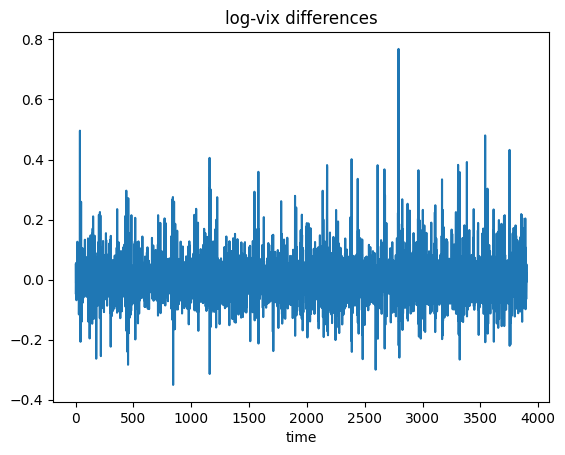

In [ ]:
df_full = pd.read_csv('/content/drive/MyDrive/spx_vol.csv')
print(df_full.head())
vix = df_full['vix'].dropna()
log_vix = np.log(vix)
y = log_vix.diff()
plt.plot(y)
plt.xlabel("time")
plt.title("log-vix differences")
plt.show()

# Kalman filter

## State space
- observable: y_t (the log-differences of VIX)
- parameters: $\beta_t$
- regressor: x_t
$$y_t = x_t^T\beta_t + e_t, \quad e_t \sim \mathcal{N}(0, R),$$
where $e_t$ is an independent noise of observations (measurement noise).


We assume the parameters $\beta_t$ evolve as a simple random walk.

The state evolution equation:
$$\beta_t = \beta_{t-1} + ϵ_t, \quad ϵ_t \sim \mathcal{N}(0, Q),$$
where Q is unknown covariance (process noise).

Then we have: $\beta_{t-1|y_1,\dots, y_{t-1}} \sim \mathcal{N}(\hat{\beta}_{t-1}, P_{t-1})$, where $P_{t-1}$ is our estimated covariance for the current previous state, given all the observed values up to that state (after update). $P^{+}_{t-1}$ is the estimate before $y_t$ is observed.

The update equations for our Kalman filter are
$$S_t =  x_t^TP_{t-1}^{+}x_t + R.$$
$$K_t = P_{t-1}^{+}x_tS_t^{-1}, \quad P_t = (I - Kx_t^T)P_{t-1}^{+}.$$

## Adaptive estimates for the measurement and process noise

The covariances R and Q are updated as an exponential moving average, where we adjust the previous variance by the one observed in this step:
$$\hat{R}_t = (1-\alpha_1)\hat{R}_{t-1} + \alpha_1 v_tv_t^T, \quad v_t = y_t - \hat{y}_t$$
$$\hat{Q}_t = (1-\alpha_2)v_t^TK^TKv_t + \alpha_2Kx_t^TP_{t-1}^{+},$$
where $\alpha_1 = 0.1, \alpha_2 = 0.05$ because we assume the parameter $\beta$ won't change that frequently.
- This is just my idea I am not sure, whether this is actually done in practise.

In [ ]:
def kalman_tv_regression(y, X, Q_diag=1e-3, R=1e-4, P0_scale=100.0, beta0=None):
    """
    Kalman filter for time-varying linear regression (random-walk state).
    :arg
      y        : array-like shape (T,)
      X        : array-like shape (T, m), regressors
      Q_diag   : scalar or array (m,), process noise
      R        : scalar, observation noise variance
      P0_scale : scalar, initial covariance P0 = P0_scale * I
      beta0    : array-like (m,), initial state

    :returns
      dict with keys:
        'beta_filtered'  : (T, m) filtered state estimates
        'y_pred'         : (T,) one-step-ahead predictions
        'innov'          : (T,) innovations v_t = y_t - y_pred
        'S'              : (T,) innovation variances
        'P'              : (T, m, m) posterior covariances (optional large mem)
        'loglik'         : log-likelihood
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    T, m = X.shape
    if beta0 is None:
        beta = np.zeros(m)
    else:
        beta = np.asarray(beta0, dtype=float).copy()

    P = np.eye(m) * P0_scale
    if np.isscalar(Q_diag):
        Q = np.eye(m) * Q_diag
    else:
        Q = np.diag(np.asarray(Q_diag, dtype=float))

    R = float(R)
    alpha1 = 0.1
    alpha2 = 0.05

    beta_hist = np.zeros((T, m))
    y_pred = np.zeros(T)
    innov = np.zeros(T)
    S_arr = np.zeros(T)
    P_hist = np.zeros((T, m, m))

    loglik = 0.0
    for t in range(T):
        xt = X[t][:, None]
        # get new parameters
        beta_pred = beta
        P_pred = P + Q

        # make prediction
        yhat = float(xt.T @ beta_pred)
        y_pred[t] = yhat
        vt = y[t] - yhat


        # update
        R = (1 - alpha1) * R + alpha1 * (vt**2)
        if R < 0.00001:
          R = 0.00001

        S = float(xt.T @ P_pred @ xt) + R
        K = (P_pred @ xt) / S

        beta = beta_pred + (K.flatten() * vt)
        P = P_pred - (K @ (xt.T @ P_pred))

        diff_beta = K.flatten() * vt
        diff_P = K @ (xt.T @ P_pred)

        Q_hat = np.diag((1-alpha2)*np.outer(diff_beta, diff_beta) + alpha2*(diff_P))
        Q = np.diag(Q_hat)


        # save data
        beta_hist[t, :] = beta
        innov[t] = vt
        S_arr[t] = S
        P_hist[t, :, :] = P

        loglik += -0.5 * (np.log(2*np.pi) + np.log(S) + (vt**2) / S)

    return {
        'beta_filtered': beta_hist,
        'y_pred': y_pred,
        'innov': innov,
        'S': S_arr,
        'P': P_hist,
        'loglik': loglik
    }


We will use the same regressor $x_t$, that was estimated in the 1st Project as the best in ARMA(2,1).

$$x_t = \begin{pmatrix}y_{t-1} & y_{t-2} & MA_y(5) & 1\end{pmatrix}$$

In [ ]:
window_ma = 5

X_df = pd.DataFrame(index=y.index)
X_df['const'] = 1.0
X_df['vix_lag1'] = y.shift(1)
X_df['vix_lag2'] = y.shift(2)
X_df['vix_ma'] = y.rolling(window=window_ma).mean().shift(1)

combined = pd.concat([y.rename('y'), X_df], axis=1).dropna()
y_clean = combined['y'].values
X_clean = combined[['vix_lag1','vix_lag2','vix_ma']].values

The MSE of our Kalman filter is compared to the MSE from naive forecast: that the $VIX_t = VIX_{t-1} ⇒ \hat{y}_t = 0$.

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-2713077326.py:29: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"residuals vs. $\Delta \log VIX$")
/tmp/ipython-input-2377723712.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(xt.T @ beta_pred)
/tmp/ipython-input-2377723712.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(xt.T @ P_pred @ xt) + R


|-------------||-------------|
MSE: 0.0061186676353378825
MSE naive:  0.006131438985248589
R2:  0.0020829286471629738
Log-lik: 5138.905088859359


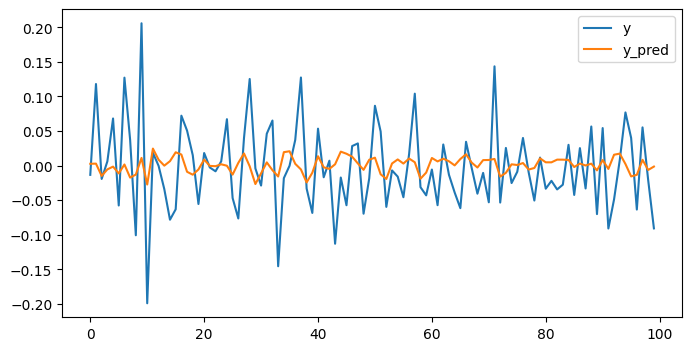

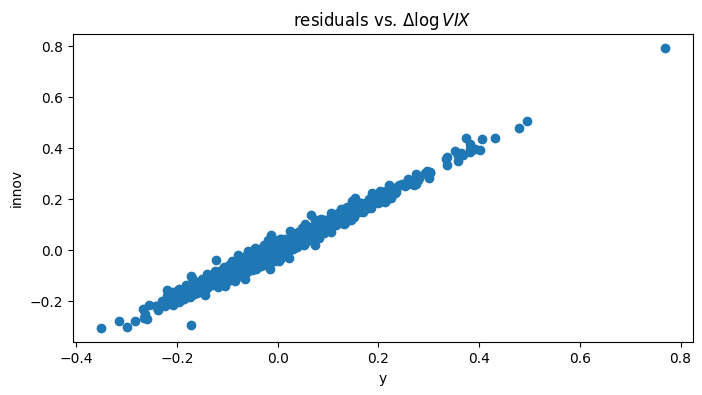

In [ ]:
res_kf = kalman_tv_regression(y_clean, X_clean,
                              Q_diag=1e-2, R=1e-1, P0_scale=1.0)

beta_t = res_kf['beta_filtered']
y_pred = res_kf['y_pred']
innov = res_kf['innov']

ss_res = np.sum(innov**2)

ss_naive = 0
for i in range(len(y_clean)):
  ss_naive += (y_clean[i])**2


print("|-------------||-------------|")
print("MSE:", ss_res/len(y_clean))
print("MSE naive: ", ss_naive/len(y_clean))
print("R2: ", 1-ss_res/ss_naive)
print("Log-lik:", res_kf['loglik'])

plt.figure(figsize=(8, 4))
plt.plot(y_clean[500:600], label='y')
plt.plot(y_pred[500:600], label='y_pred')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(y_clean, innov)
plt.title(f"residuals vs. $\Delta \log VIX$")
plt.xlabel("y")
plt.ylabel("innov")
plt.show()



MSE without the adaptive updating of Q and R: 0.0065

MSE with the adaptive update: 0.006118,

which makes the predictive $R^2$ slightly positive.

### VIX predictions
recovered from predicted differences in lon-VIX values from our Kalman filter.

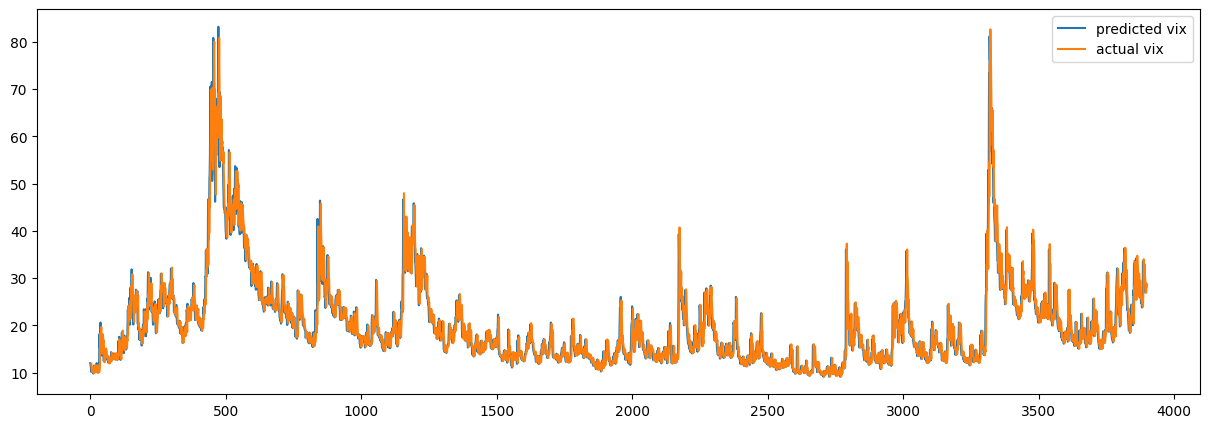

In [ ]:
v_vals = []
for i in range(len(y_pred)):
  v_vals.append(log_vix[i+3] + y_pred[i]) # at time step i, we already have access to log_vix data from the previous day

v_vals_arr = np.array(v_vals)
pred_vix = np.exp(v_vals_arr)

plt.figure(figsize=(15,5))
ax = plt.gca()
ax.plot(pred_vix, label="predicted vix")
ax.plot(vix[4:], label="actual vix")
plt.legend()
plt.show()



# UKF
*Remark: The notation $x_t$, $y_t$ has different meaning to that in Kalman filter. See below:*
- hidden state: $x_t$, the $log-VIX_t$
- observation: $y_t$, the actual $VIX$ values
- f(x): state evolution function
- h(x): measurement function


Unscented Kalman filter uses non-linear equations for the state evolution.
$$y_t = h(x_t) + e_t, \quad \mathcal{N}(0, R),$$

$$x_t = f(x_{t-1}) + w_t, \quad \mathcal{N}(0, Q).$$

The UKF takes the current mean and covariance for the state, $\bar{x}_{t-1}, P_{t-1}$, samples **sigma points** $x_i$ and transforms them with functions $f, h$ to obtain the actual mean, variance estimate.

1.   Sample **sigma points**, $x_i \sim \mathcal{N}(\bar{x}, P)$

*   Compute predicted $\bar{x}^{+}, P_{t-1}^{+}$ from these sigma points

2.   Get the state points, $x_i^{\ast} = f(x_i)$
3.   Get the predictions, $y_i = h(x_i^{\ast})$

*   Compute the predicted $y_t = \frac{1}{n} \sum_i(y_i)$

The algorithm used here is presented in article: https://groups.seas.harvard.edu/courses/cs281/papers/unscented.pdf

## Evolution equations

The state has a linar evolution (mean reversion)

$$x_t = f(x_{t-1)}) = \mu + \phi(x_{t-1} - \mu) + w_t$$

The true observed value of VIX is described by given by exponential of the log-VIX
$$y_t = h(x_t) = \exp(x_{t}) + e_t$$

parameters


*   $\mu$ - mean in the mean reversion equation (let's say $\mu = \log(20)$)
*   $\phi$ - speed of the mean reversion, close to 1: reversion takes a long time (chosen: $\phi = 0.99$)
*   Q - initial process variance
*   R - initial measurement variance



### Adaptive estimates of measurement and process noise


We are going to also use adaptive $Q$ and $R$, $\alpha_r=0.1$, $\alpha_q = 0.05$. The idea is similar to the adaptive guesses in our Kalman filter.

$$\hat{R} = (1-\alpha_r)R + \alpha_r * v^Tv,$$

$$\hat{Q} = (1 - \alpha_q)Q + \alpha_q Kv$$

I am again unsure about the correctness of my implementation. This was my simple attempt for adaptive covariance estimates.

where $S =\sum_i W_i (y_i-y_{pred})^T (y_i-y_{pred})$,

$S_{total} = S + R$

$K =  P_{xy}S_{total}^{-1}$

In [ ]:
import numpy as np
from scipy.linalg import cholesky

class UKF:
    def __init__(self, dim_x, dim_y, f, h, x0, P0, Q, R, alpha_r=0.1, alpha_q=0.5, alpha=1e-1, beta=0.5, kappa=0.):
        """
        :arg
            dim_x (int): State dimension.
            dim_y (int): Measurement dimension.
            f (callable): State transition function (f(x, dt)).
            h (callable): Measurement function (h(x)).
            x0 (np.array): Initial state estimate.
            P0 (np.array): Initial state covariance.
            Q (np.array): Process noise covariance.
            R (np.array): Measurement noise covariance.
            alpha (float): UKF tuning parameter (spread of sigma points).
            beta (float): UKF tuning parameter (incorporates prior knowledge).
            kappa (float): UKF tuning parameter.
        """
        self.dim_x = dim_x
        self.dim_y = dim_y
        self.f = f
        self.h = h

        # State and Covariance
        self.x = x0.copy()
        self.P = P0.copy()

        # Noise Covariances
        self.Q = Q.copy()
        self.R = R.copy()

        # Adaptation Parameters
        self.alpha_q = alpha_q
        self.alpha_r = alpha_r

        # Sigma Points
        self.n = dim_x
        self.n_sigma = 2 * self.n + 1

        # params
        self.alpha = alpha
        self.beta = beta
        self.kappa = kappa

        self.lambda_ = self.alpha**2 * (self.n + self.kappa) - self.n

        # Calculate Sigma Point Weights
        self.W_m = np.full(self.n_sigma, 1 / (2 * (self.n + self.lambda_)))
        self.W_c = np.full(self.n_sigma, 1 / (2 * (self.n + self.lambda_)))

        # Weights for the 0th sigma point
        self.W_m[0] = self.lambda_ / (self.n + self.lambda_)
        self.W_c[0] = (self.lambda_ / (self.n + self.lambda_)) + (1 - self.alpha**2 + self.beta)

        self.X_sigma_pred = np.zeros((self.n_sigma, self.n))

    def _generate_sigma_points(self):
        """
        Generates sigma points based on the current state and covariance x, P.
        """
        sigma_points = np.zeros((self.n_sigma, self.n))

        try:
            L = cholesky((self.n + self.lambda_) * self.P)
        except np.linalg.LinAlgError:
            L = cholesky((self.n + self.lambda_) * self.P + 1e-6 * np.eye(self.n))

        sigma_points[0] = self.x

        for i in range(self.n):
            sigma_points[i + 1] = self.x + L[i]
            sigma_points[i + 1 + self.n] = self.x - L[i]

        return sigma_points

    def predict(self, dt=1.0, **f_kwargs):
        """
        Performs the predict step of the UKF.
        """
        # 1. Generate sigma points
        X_sigma = self._generate_sigma_points()

        # 2. Get the predicted next state
        for i in range(self.n_sigma):
            self.X_sigma_pred[i] = self.f(X_sigma[i], dt, **f_kwargs)

        # 3. Calculate predicted mean
        self.x = np.dot(self.W_m, self.X_sigma_pred)

        # 4. Calculate predicted covariance
        self.P = np.zeros((self.n, self.n))
        for i in range(self.n_sigma):
            diff = self.X_sigma_pred[i] - self.x
            self.P += self.W_c[i] * np.outer(diff, diff)

        # Add process noise
        self.P += self.Q

    def update(self, y, **h_kwargs):
        """
        Performs the update step of the UKF.
        """
        # 1. Get the predicted y
        Y_sigma_pred = np.zeros((self.n_sigma, self.dim_y))
        for i in range(self.n_sigma):
            Y_sigma_pred[i] = self.h(self.X_sigma_pred[i], **h_kwargs)

        # 2. Calculate predicted (weighted) y mean
        y_pred = np.dot(self.W_m, Y_sigma_pred)

        # 3. Calculate cross-covariance P_xy and innovation covariance S
        S = np.zeros((self.dim_y, self.dim_y))
        P_xy = np.zeros((self.n, self.dim_y))

        for i in range(self.n_sigma):
            diff_x = self.X_sigma_pred[i] - self.x
            diff_y = Y_sigma_pred[i] - y_pred

            S += self.W_c[i] * np.outer(diff_y, diff_y)
            P_xy += self.W_c[i] * np.outer(diff_x, diff_y)

        S_total = S + self.R

        # 4. Calculate Kalman gain K
        K = np.dot(P_xy, np.linalg.inv(S_total))

        # 5. Update state
        v = y - y_pred
        self.x = self.x + np.dot(K, v)

        # 6. Update covariance
        self.P = self.P - np.dot(K, np.dot(S_total, K.T))

        # 7. Adaptively update covariances R an Q
        res_sq = np.outer(v, v)
        self.R = (1-self.alpha_r)*self.R + self.alpha_r * res_sq
        self.R = np.maximum(self.R, 1e-2 * np.eye(self.dim_y))

        dx = np.dot(K, v)
        dx_sq = np.outer(dx, dx)

        self.Q = (1 - self.alpha_q)*self.Q + self.alpha_q * dx_sq
        self.Q = np.maximum(self.Q, 1e-2 * np.eye(self.dim_x))



Using Parameters: mu=2.9957, phi=0.9900
Using Noise: Q=0.010000, R=0.500000


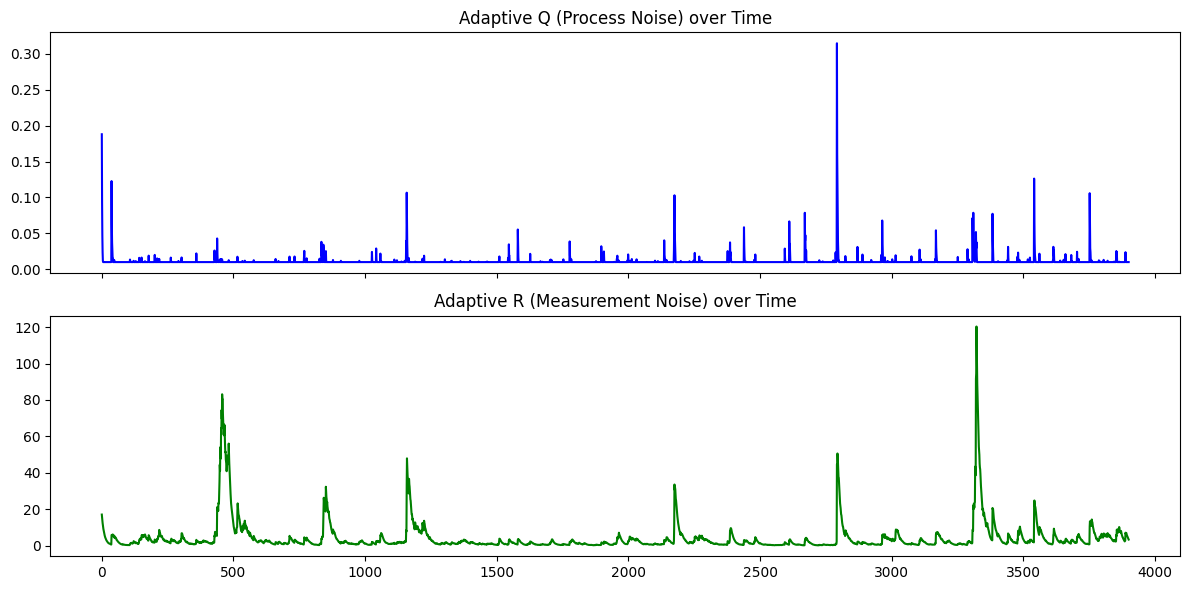

In [ ]:
def f_state_vix(x, dt, mu, phi):
    """
    State transition: Mean-reverting AR(1) process on log-volatility (x[0]).
    x_t = mu + phi * (x_t-1 - mu)
    """
    # x is a 1D array [log_vix]
    x_new = mu + phi * (x[0] - mu)
    return np.array([x_new])

def h_measurement_vix(x):
    """
    Measurement function: We observe the VIX, which is exp(log-volatility).
    y = exp(x[0])
    """
    # x is a 1D array [log_vix]
    return np.array([np.exp(x[0])])


# --- 2. Main Execution ---
if __name__ == "__main__":

    param_mu = np.log(20)
    param_phi = 0.99

    Q_val = 0.01
    R_val = 0.5

    print(f"Using Parameters: mu={param_mu:.4f}, phi={param_phi:.4f}")
    print(f"Using Noise: Q={Q_val:.6f}, R={R_val:.6f}")

    Q_init = np.array([[Q_val]])
    R_init = np.array([[R_val]])

    x0 = np.array([param_mu])
    P0_val = Q_val / (1 - param_phi**2) if (1 - param_phi**2) > 1e-6 else 1.0
    P0 = np.array([[P0_val]])

    ukf = UKF(dim_x=1, dim_y=1,
              f=f_state_vix,
              h=h_measurement_vix,
              x0=x0, P0=P0, Q=Q_init, R=R_init)

    # --- 2e. Run the Filter ---
    filtered_states_log_vix = []
    predicted_states_log_vix = []
    res = []
    Q_history = []
    R_history = []

    for y_obs in vix:
        # Pass your pre-defined model params to the state function
        ukf.predict(dt=1.0, mu=param_mu, phi=param_phi)
        predicted_states_log_vix.append(ukf.x.copy())

        # Update with the measurement (as a 1D array)
        ukf.update(np.array([y_obs]))

        # Store the filtered state
        filtered_states_log_vix.append(ukf.x.copy())
        Y_sigma_pred = np.zeros((ukf.n_sigma, ukf.dim_y))
        for i in range(ukf.n_sigma):
            Y_sigma_pred[i] = ukf.h(ukf.X_sigma_pred[i])
        y_pred = np.dot(ukf.W_m, Y_sigma_pred) # This is your predicted VIX_t|t-1
        Q_history.append(ukf.Q[0,0])
        R_history.append(ukf.R[0,0])

        # Now you can get the residual:
        res.append(y_obs - y_pred[0])



    # Convert state (log-vix) back to VIX level for plotting
    filtered_states_vix = np.exp(np.array(filtered_states_log_vix).squeeze())
    predicted_states_vix = np.exp(np.array(predicted_states_log_vix).squeeze())
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax[0].plot(Q_history, 'b-')
    ax[0].set_title("Adaptive Q (Process Noise) over Time")

    ax[1].plot(R_history, 'g-')
    ax[1].set_title("Adaptive R (Measurement Noise) over Time")

    plt.tight_layout()
    plt.show()



We can see that the adaptive R recognizes the schocks in VIX values and reverts back to its initial value but the estimate for Q just keeps rising. This is also influenced by initial settings of $Q, R, \alpha_q, \alpha_q, \phi$. I gave some time to manually tune these parameters but was unable to beat the MSE of the naive prediciton.

The next logical step would be to divide the dataset into training and validation sets, optimize for Q, R and use these as constants in validation. I wanted to make fully online algorithm but this might be a better approach.

In [ ]:
mse = np.mean(np.array(res)**2)
mse_naive = np.mean(vix.diff()**2)
print("MSE:", mse)
print("MSE naive: ", mse_naive)

MSE: 4.257460660720527
MSE naive:  4.208342023687211


MSE for the non-adaptive case: 4.369...

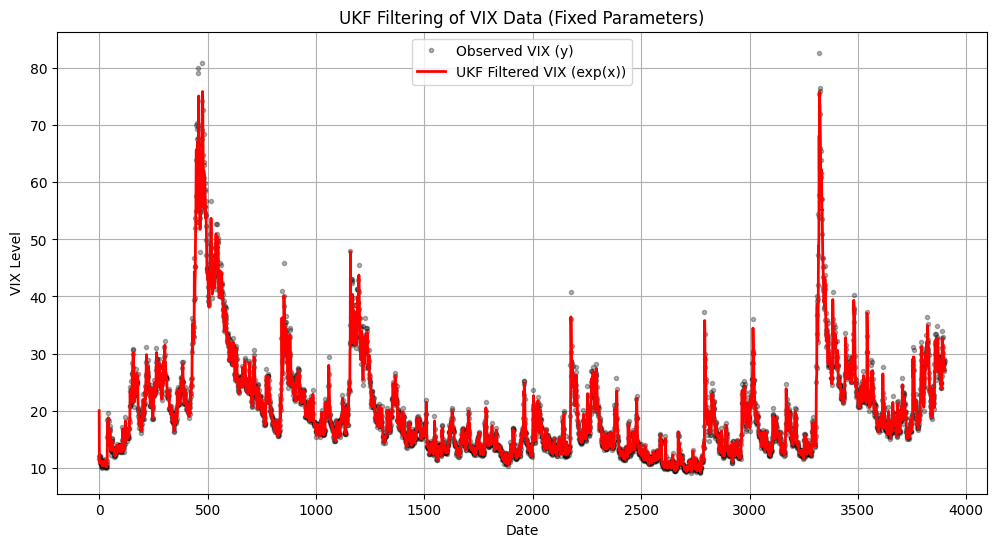

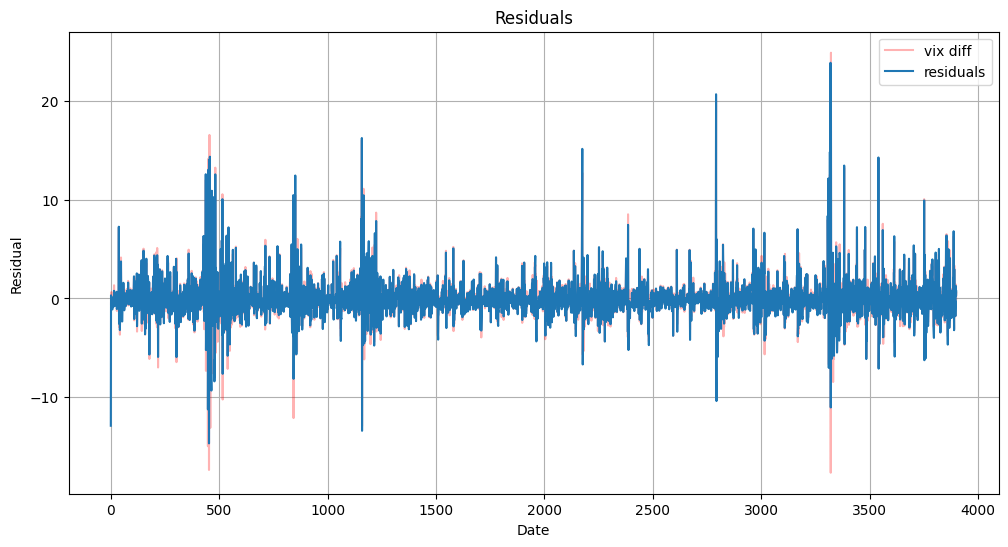

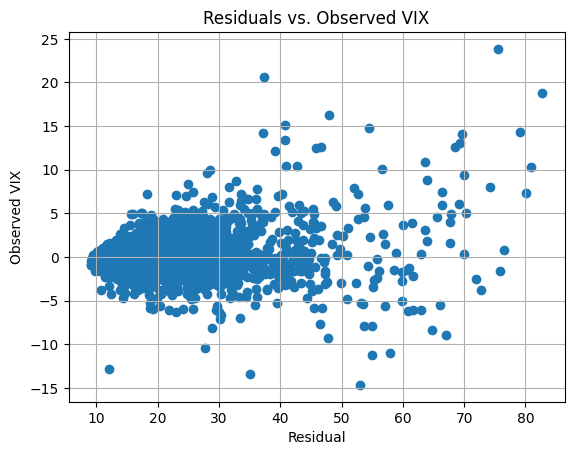

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(vix, 'k.', alpha=0.3, label='Observed VIX (y)')
plt.plot(predicted_states_vix, 'r-', linewidth=2, label='UKF Filtered VIX (exp(x))')
plt.title('UKF Filtering of VIX Data (Fixed Parameters)')
plt.xlabel('Date')
plt.ylabel('VIX Level')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(vix.diff(), color='red', alpha = 0.3, label='vix diff')
plt.plot(res, label='residuals')
plt.title('Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.legend()
plt.show()

plt.scatter(vix, res)
plt.title('Residuals vs. Observed VIX')
plt.xlabel('Residual')
plt.ylabel('Observed VIX')
plt.grid(True)
plt.show()

The residuals plot shows more significant heteroskedasticity than I would expect.

## Conclusions

The adaptive estimation of covariances R and Q seem to benefit the predictions (in MSE). The performance of our Kalman filter on the differences of log-VIX values performed better than the UKF on the actual VIX values under MSE metric.

As expected, the Kalman filter predicts values close to zero and was barely able to outperform the naive prediction. While the UKF failed to outperform this simple benchmark.

Possible improvements:
- optimize the used hyperparameter (possibly at each time step, using the past data)
- inspect other regressors and their significance (we just used the past 2 observations, moving average and intercept), these were not the primary concern of this Project but it is the next logical step for improvements
- bagging: combine the predictions given by our models and estimate the mixing coefficients, this would allow us to make multiple models and investigate which ones are good in predicting the implied volatility

# PROJECT 3


## SIMPLE BAGGING
We are going to use the mixed predictions
$$\hat{y} = \varphi * y^{pred}_{UFK} + (1-\varphi) * y^{pred}_{Kalman}$$

The mixing coefficient $\varphi$ will be estimated by a very simple RNN.

*These predictions will come from the models in Project 2, which are not greatly optimized. Again, this Project (3) does not aim to provide the best models, it makes a skeleton for mixing models. The mixed model will serve to provide a predicted volatility to estimate prices of OTM (out of the money) European call option.*

We are going to use a very simple LSTM to predict the mixing coefficent $\varphi$.

We use $10\%$ of the data for training.

In [ ]:
from sklearn.model_selection import train_test_split

aligned_vix = vix[4:4+len(pred_vix)].values

aligned_predicted_states_vix = predicted_states_vix[4:4+len(pred_vix)]

print(f"Length of aligned_vix: {len(aligned_vix)}")
print(f"Length of pred_vix: {len(pred_vix)}")
print(f"Length of aligned_predicted_states_vix: {len(aligned_predicted_states_vix)}")

df_rnn_data = pd.DataFrame({
    'actual_vix': aligned_vix,
    'kf_pred_vix': pred_vix,
    'ukf_pred_vix': aligned_predicted_states_vix
})

print("\nDataFrame head:")
print(df_rnn_data.head())

X = df_rnn_data[['kf_pred_vix', 'ukf_pred_vix']]

y = df_rnn_data['actual_vix']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Length of aligned_vix: 3895
Length of pred_vix: 3895
Length of aligned_predicted_states_vix: 3895

DataFrame head:
   actual_vix  kf_pred_vix  ukf_pred_vix
0       11.91    12.000000     11.127885
1       11.47    11.893010     11.271128
2       10.87    11.393254     11.231604
3       10.15    10.885946     11.045323
4       10.74    10.156536     10.726131

Shape of X_train: (3505, 2)
Shape of X_test: (390, 2)
Shape of y_train: (3505,)
Shape of y_test: (390,)


## RNN Model Parameters Summary


*   **Input Size (`input_size = 2`)**:
    *   Number of features the RNN takes at each time step: `kf_pred_vix` (Kalman Filter prediction) and `ukf_pred_vix` (Unscented Kalman Filter prediction).

*   **Hidden Size (`hidden_size = 20`)**:
    *   This determines the number of memory units (neurons) in the LSTM layer. We just need a very simple network because our input size is very small

*   **Output Size (`output_size = 1`)**:
    *   This is the dimension of the final output from the network. RNN outputs a single value: the mixing coefficient $\varphi$.
*   **Epochs (`epoch = 30`)**
*   **learning rate (`lr = 0.001`)**
*   **batch size (`batch_size = 16`)**

### Model Layers:

1.  **`nn.LSTM` Layer (Long Short-Term Memory)**:
    *   This LSTM acts as a processing unit for the `kf_pred_vix` and `ukf_pred_vix` inputs.

2.  **`nn.Linear` Layer (Dense/Fully Connected)**:
    *   Takes the output from the LSTM layer (which has `hidden_size` dimensions) and transforms it into the desired `output_size` (1 dimension for $\varphi$).

3.  **`nn.Sigmoid` Activation Function**



In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

X_train_rnn = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_rnn = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

y_train_modified = np.stack([y_train.values, X_train['kf_pred_vix'].values, X_train['ukf_pred_vix'].values], axis=1)
y_test_modified = np.stack([y_test.values, X_test['kf_pred_vix'].values, X_test['ukf_pred_vix'].values], axis=1)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_rnn, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_rnn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_modified, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_modified, dtype=torch.float32)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

class VIXDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = VIXDataset(X_train_tensor, y_train_tensor)
test_dataset = VIXDataset(X_test_tensor, y_test_tensor)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in training DataLoader: {len(train_dataloader)}")
print(f"Number of batches in test DataLoader: {len(test_dataloader)}")

X_train_tensor shape: torch.Size([3505, 1, 2])
y_train_tensor shape: torch.Size([3505, 3])
Training dataset size: 3505
Test dataset size: 390
Number of batches in training DataLoader: 220
Number of batches in test DataLoader: 25


In [ ]:
import torch.nn as nn

class MixingRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super(MixingRNN, self).__init__()
        # Define an nn.LSTM layer

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        linear_in = lstm_out[:, -1, :]

        phi_raw = self.linear(linear_in)

        phi = self.sigmoid(phi_raw)

        return phi

input_size = X_train_tensor.shape[2]
hidden_size = 20

model_pytorch = MixingRNN(input_size=input_size, hidden_size=hidden_size)

print("PyTorch MixingRNN Model Summary:")
print(model_pytorch)
dummy_input = torch.randn(16, 1, input_size)
dummy_output = model_pytorch(dummy_input)
print(f"\nDummy input shape: {dummy_input.shape}")
print(f"Dummy output shape: {dummy_output.shape}")


PyTorch MixingRNN Model Summary:
MixingRNN(
  (lstm): LSTM(2, 20, batch_first=True)
  (linear): Linear(in_features=20, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Dummy input shape: torch.Size([16, 1, 2])
Dummy output shape: torch.Size([16, 1])


In [ ]:
# Define custom_mixing_mse_loss
def custom_mixing_mse_loss(y_true, phi_pred):
    actual_vix = y_true[:, 0]
    kf_pred = y_true[:, 1]
    ukf_pred = y_true[:, 2]
    combined_pred = phi_pred * ukf_pred.unsqueeze(1) + (1 - phi_pred) * kf_pred.unsqueeze(1)

    combined_pred = combined_pred.squeeze(1)

    # Compute the Mean Squared Error (MSE)
    mse = torch.mean(torch.square(actual_vix - combined_pred))
    return mse

In [ ]:
import torch.optim as optim

model_pytorch = MixingRNN(input_size=input_size, hidden_size=hidden_size)
optimizer = optim.Adam(model_pytorch.parameters(), lr=0.001)

epochs = 30

# Training loop
print("\nTraining the PyTorch RNN model...")

for epoch in range(epochs):
    model_pytorch.train()
    train_loss = 0.0
    for batch_X, batch_y in train_dataloader:
        optimizer.zero_grad()

        phi_pred = model_pytorch(batch_X)
        loss = custom_mixing_mse_loss(batch_y, phi_pred)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dataloader)

    model_pytorch.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_X_test, batch_y_test in test_dataloader:
            phi_pred_test = model_pytorch(batch_X_test)
            loss_test = custom_mixing_mse_loss(batch_y_test, phi_pred_test)
            test_loss += loss_test.item()

    avg_test_loss = test_loss / len(test_dataloader)

    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')

print("PyTorch RNN model training complete.")


Training the PyTorch RNN model...
Epoch [1/30], Train Loss: 4.2458, Test Loss: 4.4395
Epoch [2/30], Train Loss: 4.1843, Test Loss: 4.4453
Epoch [3/30], Train Loss: 4.1763, Test Loss: 4.4518
Epoch [4/30], Train Loss: 4.2007, Test Loss: 4.4561
Epoch [5/30], Train Loss: 4.1625, Test Loss: 4.4564
Epoch [6/30], Train Loss: 4.1607, Test Loss: 4.4587
Epoch [7/30], Train Loss: 4.1619, Test Loss: 4.4572
Epoch [8/30], Train Loss: 4.2098, Test Loss: 4.4582
Epoch [9/30], Train Loss: 4.1610, Test Loss: 4.4583
Epoch [10/30], Train Loss: 4.2480, Test Loss: 4.4580
Epoch [11/30], Train Loss: 4.1595, Test Loss: 4.4591
Epoch [12/30], Train Loss: 4.1594, Test Loss: 4.4587
Epoch [13/30], Train Loss: 4.4944, Test Loss: 4.4599
Epoch [14/30], Train Loss: 4.1582, Test Loss: 4.4601
Epoch [15/30], Train Loss: 4.1583, Test Loss: 4.4613
Epoch [16/30], Train Loss: 4.1596, Test Loss: 4.4611
Epoch [17/30], Train Loss: 4.1950, Test Loss: 4.4614
Epoch [18/30], Train Loss: 4.1617, Test Loss: 4.4616
Epoch [19/30], Train

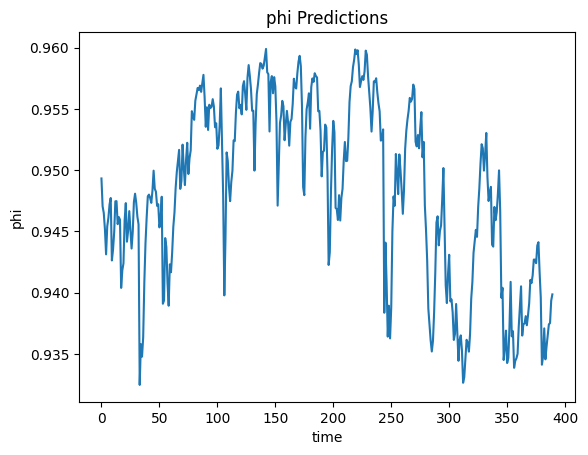

MSE on test data
-----------------
Kalman filter:  4.728659127883612
UKF:  4.55937089567043
Combined:  4.546340390030116


In [ ]:
# Set the model to evaluation mode
model_pytorch.eval()

phi_predictions = []

# Iterate through the test data to get phi predictions
with torch.no_grad(): # Disable gradient calculation for inference
    for batch_X_test, _ in test_dataloader:
        phi_pred_batch = model_pytorch(batch_X_test)
        phi_predictions.append(phi_pred_batch.cpu().numpy())

# Concatenate all batch predictions into a single array
phi_predictions_np = np.concatenate(phi_predictions, axis=0)

plt.plot(phi_predictions_np)
plt.title("phi Predictions")
plt.xlabel("time")
plt.ylabel("phi")
plt.show()

actual_vix_test = y_test_modified[:, 0]
kf_pred_test = y_test_modified[:, 1]
ukf_pred_test = y_test_modified[:, 2]

phi_predictions_np = np.concatenate(phi_predictions, axis=0).flatten()

combined_pred_test = phi_predictions_np * ukf_pred_test + (1 - phi_predictions_np) * kf_pred_test
mse_kf_test = np.mean((kf_pred_test - actual_vix_test)**2)
mse_ukf_test = np.mean((ukf_pred_test - actual_vix_test)**2)
mse_combined = np.mean((combined_pred_test - actual_vix_test)**2)

print("MSE on test data")
print("-----------------")
print("Kalman filter: ", mse_kf_test)
print("UKF: ", mse_ukf_test)
print("Combined: ", mse_combined)

We see that the train loss decreaes slightly by epoch, while validation loss stays about the same. This hints on very noisy data and possible overfitting.

The MSE of the combined prediction is a little smaller on the test data but not significantly smaller by any means.

# Black-Sholes
- for European call options.

We calculate the theoretical call option prices using `actual_vix_test` as the 'actual' volatility and `combined_pred_test` as the 'predicted' volatility.

We define a simple buy rule where an option is 'bought' if the price calculated with `combined_pred_test` VIX is significantly higher than the price with `actual_vix_test` (15\% or above).

Then we visualize the actual and predicted option prices, highlighting the buy signals.

In [ ]:
start_index_df_rnn_data = len(y_train)
end_index_df_rnn_data = len(df_rnn_data) - 1

# df_rnn_data starts at index 4 of df_full
# So, the corresponding indices in df_full are:
start_index_df_full = 4 + start_index_df_rnn_data
end_index_df_full = 4 + end_index_df_rnn_data

print(f"Start index in df_full for y_test: {start_index_df_full}")
print(f"End index in df_full for y_test: {end_index_df_full}")

# Extract 'spy' values from df_full corresponding to y_test
spy_test_data = df_full.loc[start_index_df_full:end_index_df_full, 'spy'].values

print(f"Shape of spy_test_data: {spy_test_data.shape}")
print("First 5 spy_test_data values:", spy_test_data[:5])
print("Last 5 spy_test_data values:", spy_test_data[-5:])

Start index in df_full for y_test: 3509
End index in df_full for y_test: 3898
Shape of spy_test_data: (390,)
First 5 spy_test_data values: [366.85 366.73 366.3  364.66 369.59]
Last 5 spy_test_data values: [374.39 378.06 390.08 388.59 380.65]


The Black-Sholes formula is given as:
$$C = S N(d_1) - K e^{-rT} N(d_2)$$

where:
$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma \sqrt{T}$

S = Current stock price

K = Strike price (actual price + 10)

T = Time to expiration (in years)

r = Risk-free interest rate (annualized)

$\sigma$ = Volatility of the underlying stock (annualized)

N(x) = Cumulative standard normal distribution function

In [ ]:
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    """
    Calculates the Black-Scholes price of a European call option.

    :param S: Current stock price
    :param K: Strike price
    :param T: Time to expiration (in years)
    :param r: Risk-free interest rate (annualized)
    :param sigma: Volatility of the underlying stock (annualized)
    :return: Call option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = (S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    return call_price

In [ ]:
import numpy as np

T = 30/365             # Time to expiration: 30 days (in years)
r = 0.04               # Risk-free interest rate: 4% (annualized)

print(f"Assumed Black-Scholes Parameters:\nTime to Expiration (T): {T:.3f} years\nRisk-Free Rate (r): {r:.2%}\nStrike Price (K): Dynamic (Current SPY Price + 10)")

# --- Calculate theoretical call option prices ---
actual_option_prices = []
predicted_option_prices = []
strike_prices_used = [] # Store dynamic K values for P&L calculation

for i in range(len(spy_test_data)):
    S = spy_test_data[i]
    dynamic_K = S + 10 # Strike price is current SPY price + 10

    sigma_actual = actual_vix_test[i] / 100.0
    sigma_predicted = combined_pred_test[i] / 100.0

    if sigma_actual <= 0: sigma_actual = 0.001
    if sigma_predicted <= 0: sigma_predicted = 0.001

    actual_option_prices.append(black_scholes_call(S, dynamic_K, T, r, sigma_actual))
    predicted_option_prices.append(black_scholes_call(S, dynamic_K, T, r, sigma_predicted))
    strike_prices_used.append(dynamic_K)

actual_option_prices = np.array(actual_option_prices)
predicted_option_prices = np.array(predicted_option_prices)
strike_prices_used = np.array(strike_prices_used)

print(f"\nCalculated {len(actual_option_prices)} actual option prices.")
print(f"Calculated {len(predicted_option_prices)} predicted option prices.")
print("First 5 actual option prices:", actual_option_prices[:5])
print("First 5 predicted option prices:", predicted_option_prices[:5])
print("First 5 dynamic strike prices used:", strike_prices_used[:5])

Assumed Black-Scholes Parameters:
Time to Expiration (T): 0.082 years
Risk-Free Rate (r): 4.00%
Strike Price (K): Dynamic (Current SPY Price + 10)

Calculated 390 actual option prices.
Calculated 390 predicted option prices.
First 5 actual option prices: [5.71116547 5.8072904  6.11017088 6.62756615 6.02772117]
First 5 predicted option prices: [5.07519128 5.53483555 5.68790367 5.93802234 6.59312021]
First 5 dynamic strike prices used: [376.85 376.73 376.3  374.66 379.59]


In [ ]:
price_threshold = 0.15

buy_signals = predicted_option_prices > (actual_option_prices * (1 + price_threshold))

print(f"Number of buy signals (Predicted > Actual + {price_threshold:.0%}): {np.sum(buy_signals)}")
print(f"Percentage of buy signals (Predicted > Actual + {price_threshold:.0%}): {np.sum(buy_signals) / len(buy_signals) * 100:.2f}%")

Number of buy signals (Predicted > Actual + 15%): 32
Percentage of buy signals (Predicted > Actual + 15%): 8.21%


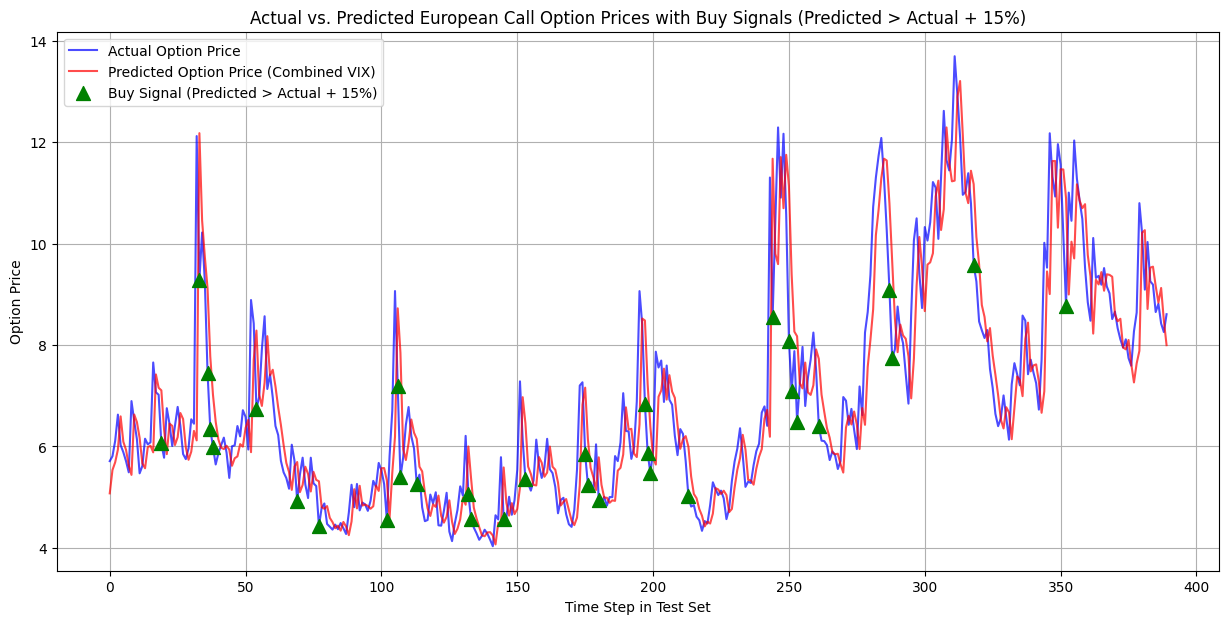

In [ ]:
price_threshold = 0.15

plt.figure(figsize=(15, 7))
plt.plot(actual_option_prices, label='Actual Option Price', alpha=0.7, color='blue')
plt.plot(predicted_option_prices, label='Predicted Option Price (Combined VIX)', alpha=0.7, color='red')

# Highlight buy signals
buy_indices = np.where(buy_signals)[0]
plt.scatter(buy_indices, actual_option_prices[buy_indices], marker='^', color='green', s=100, label=f'Buy Signal (Predicted > Actual + {price_threshold:.0%})', zorder=5)

plt.title(f'Actual vs. Predicted European Call Option Prices with Buy Signals (Predicted > Actual + {price_threshold:.0%})')
plt.xlabel('Time Step in Test Set')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.show()

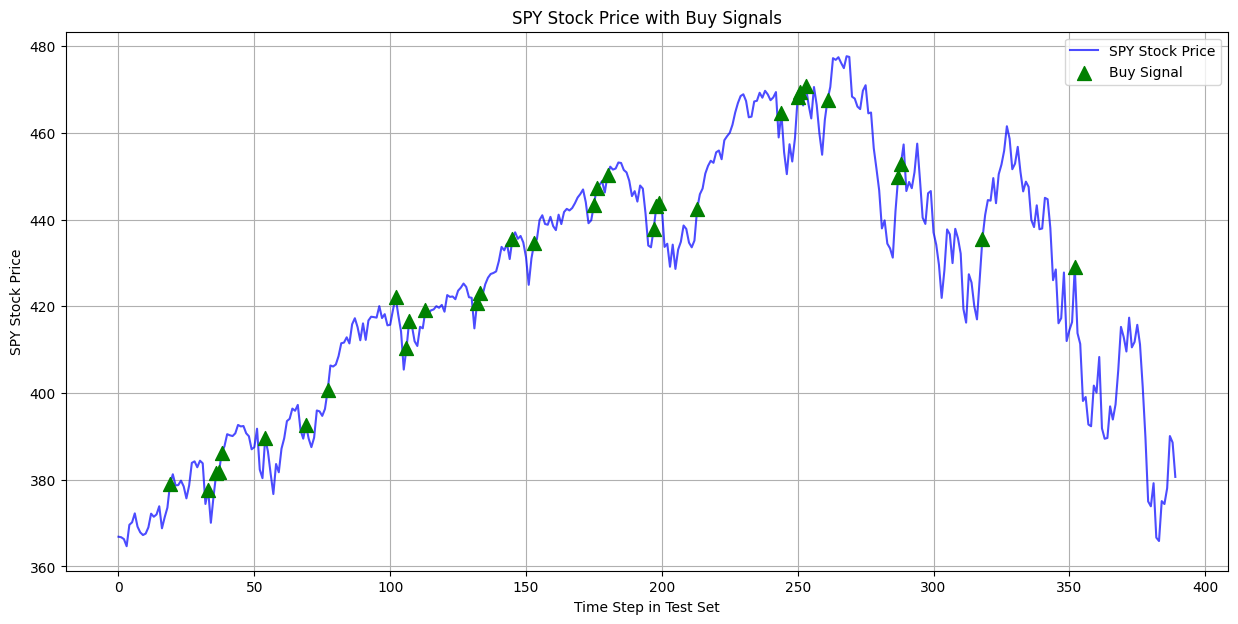

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(spy_test_data, label='SPY Stock Price', alpha=0.7, color='blue')

# Highlight buy signals on the SPY chart
buy_indices = np.where(buy_signals)[0]
plt.scatter(buy_indices, spy_test_data[buy_indices], marker='^', color='green', s=100, label='Buy Signal', zorder=5)

plt.title('SPY Stock Price with Buy Signals')
plt.xlabel('Time Step in Test Set')
plt.ylabel('SPY Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
instantaneous_pnl = np.zeros_like(actual_option_prices)

df_full['date'] = pd.to_datetime(df_full['date'])

original_df_indices_for_test = df_full.loc[start_index_df_full:end_index_df_full].index

for i in range(len(spy_test_data)):
    if buy_signals[i]:
        cost_of_option = actual_option_prices[i]

        # Retrieve the dynamic strike price used for this day's option
        current_K = strike_prices_used[i]

        # Get the current date for this signal from the original df_full
        signal_date = df_full.loc[original_df_indices_for_test[i], 'date']

        # Calculate the expiration date (30 days later)
        expiration_date = signal_date + pd.Timedelta(days=30)

        # Find the SPY price at expiration
        S_T = 0.0 # Default to 0 (worthless) if expiration is beyond dataset or no price found

        # Find the index of the expiration_date or the next available date in df_full
        idx_after_expiration = df_full['date'].searchsorted(expiration_date, side='left')

        if idx_after_expiration < len(df_full):
            # If there's a date in df_full on or after expiration_date, use its SPY price
            S_T = df_full.loc[df_full.index[idx_after_expiration], 'spy']
        else:
            # Expiration date is beyond the end of the available data
            # The option expires worthless if not already covered by in-the-money on signal date
            S_T = 0.0 # Option expires worthless

        # Hypothetical value of the option at expiration
        value_at_expiration = max(0, S_T - current_K)

        # Calculate the P&L for this option
        instantaneous_pnl[i] = value_at_expiration - cost_of_option

accumulated_pnl = np.cumsum(instantaneous_pnl)

print(f"Total number of buy signals: {np.sum(buy_signals)}")
print(f"First 5 instantaneous P&L values (where a signal occurred): {instantaneous_pnl[buy_signals][:5]}")
print(f"First 5 accumulated P&L values: {accumulated_pnl[:5]}")
print(f"Final accumulated P&L: {accumulated_pnl[-1]:.2f}")

Total number of buy signals: 32
First 5 instantaneous P&L values (where a signal occurred): [-4.64832881 -7.33693631 -7.4527811  -6.35198852 -5.98527599]
First 5 accumulated P&L values: [0. 0. 0. 0. 0.]
Final accumulated P&L: -141.67


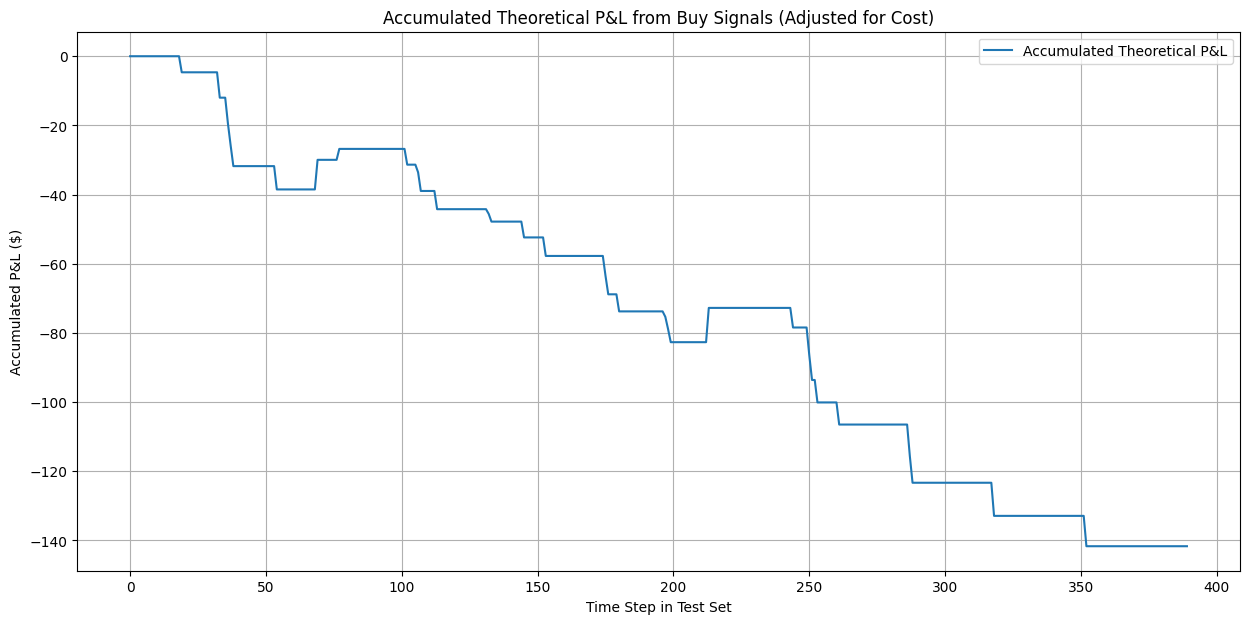

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(accumulated_pnl, label='Accumulated Theoretical P&L')

plt.title('Accumulated Theoretical P&L from Buy Signals (Adjusted for Cost)')
plt.xlabel('Time Step in Test Set')
plt.ylabel('Accumulated P&L ($)')
plt.legend()
plt.grid(True)
plt.show()

The gain is calculated as: $max(0, S_T - K_c)$, where $S_T$ is current price and $K_c$ is current strike price for that option, the price of the option is subtracted from the price at expiration date (30 days after purchase).

Currently: the model does not perform well, although just by looking at the Buy Signals on the chart, most of them were good in my oppinion.

The substantial losses are expected with such a simple model but they also may be due to the value of the option at expiration being misscalculated or also because I misscalculated the 'actual prices' of the options, which I did not have (the were estimated from the actual VIX values).

## Summary
In my 3 Project I:
- Analysed the implied volatility as a time series, estimating AR, ARMA and ARIMA processes.
- Made a Kalman filter for the differences of log-VIX values
- Implemented the UKF for actual VIX values
- Implemented a simple LSTM for predicting the mixing coefficinet for my KF, UKF models
- Calculated the price of European call option based on predicted VIX values
- Designed a decision rule for, where to buy the option
- Evaluated all of the models and final PNL with my strategy

## Conclusions
Working with financial data is very hard and demanding (I also work with this data in my thesis). Fine tunning the models for a given time period simply does not work in the long run, which is why I tried to implement adaptive estimates. The bagging of multiple models could work as a regime-switching policy if we estimated multiple models for various market scenarios but we always have to think about not overfitting the data.

The simple buying rule is fine in my oppinon but I would need to get the real data for the prices of these options to obtain more accurate results.

In conclusion, I am happy I've learned and applied multiple techniques.